In [17]:
import pandas as pd

In [18]:
weights = pd.read_csv("original_data/weights1.csv")
weights2 = pd.read_csv("original_data/weights2.csv")
weights = pd.concat([weights, weights2], ignore_index=True)
weights

,OCCURNUM,qstnum,repwgt0,repwgt1,repwgt2,repwgt3,repwgt4,repwgt5,repwgt6,repwgt7,...,repwgt151,repwgt152,repwgt153,repwgt154,repwgt155,repwgt156,repwgt157,repwgt158,repwgt159,repwgt160
0,1,14,18354163,10438492,10407387,28068302,25562833,9239434,25338398,25701567,...,10895492,31037674,9263588,24989376,8651019,23992521,27458755,22802523,26921460,9028737
1,2,14,15592437,8650848,7739514,23599044,22150186,7661903,20928499,24058785,...,9142763,27457903,8064288,19715055,7889177,20023445,24539323,20821892,22804294,7763269
2,1,15,16356249,8971846,7819705,24359971,21130796,8033700,24966868,21950496,...,8970494,22956112,9292178,25490285,7864233,23294925,19066812,23322929,23187256,8032997
3,1,16,20773863,12256987,10094193,28950309,26670581,8927895,30159278,31383567,...,12579129,30210036,11522337,27180683,9795101,25067470,27903109,29132044,28331760,10088447
4,2,16,16796510,9358118,8017431,25625108,24611988,8170753,24141884,24525276,...,9598023,22642743,10367559,21832240,9384531,22057325,25366842,23213102,23656517,8461291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99058,1,69460,3872403,3811524,3867477,1184134,6392906,3869526,3833685,4185059,...,3946475,3955011,4098830,1141866,7098608,1220946,4046508,6799129,5947367,7015049
99059,1,69461,3872403,3811524,3867477,1184134,6392906,3869526,3833685,4185059,...,3946475,3955011,4098830,1141866,7098608,1220946,4046508,6799129,5947367,7015049
99060,2,69461,3332493,3369042,3339441,1046782,5289272,3467648,3184734,3487858,...,3398154,3455348,3389339,972960,5565823,1068255,3141941,5549270,5110794,5729614
99061,1,69464,2790829,2731309,837142,830413,4724120,5051157,2624563,5274098,...,4617975,2631165,807997,2960079,812894,4881043,2910442,964690,834369,2604438


In [19]:
data = pd.read_csv('original_data/nov24pub_first_half.csv')
data2 = pd.read_csv('original_data/nov24pub_second_half.csv')
data = pd.concat([data, data2], ignore_index=True)
data

,HRHHID,HRMONTH,HRYEAR4,HURESPLI,HUFINAL,FILLER,HETENURE,HEHOUSUT,HETELHHD,HETELAVL,...,PRSUPINT,PES1,PES2,PES3,PES4,PES5,PES6,PES7,PRS8,PESCK4
0,84055620110148,11,2024,-1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
1,521800504640811,11,2024,1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,510421864001780,11,2024,-1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
3,7180159540041,11,2024,-1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
4,71062004118993,11,2024,-1,219,NaN,1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126681,658604017243570,11,2024,-1,218,NaN,2,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
126682,140784500685805,11,2024,-1,218,NaN,1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
126683,181202500665725,11,2024,1,218,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
126684,940325328011460,11,2024,1,218,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [45]:
(data.where(data == -1).count() / len(data) * 100).sort_values(ascending=False).head(200)
# We can also get rid of columns that have a certain percentage of NA values, as these are also likely to be uninformative. 
# We can also get rid of columns that have a certain percentage of 0 values, as these are also likely to be uninformative. 

PULKDK4     100.000000
PULKPS5     100.000000
PULKPS4     100.000000
PULKPS6     100.000000
PULKDK6     100.000000
               ...    
PUIODP1      76.211262
PXNLFACT     73.802157
PXDWLKWK     73.802157
PXRET1       73.802157
PXDWAVL      73.802157
Length: 200, dtype: float64

In [21]:
for df_name in ['data', 'data2']:
    if df_name in globals():
        df = globals()[df_name]
        keep = ~(df == -1).all(axis=1)
        globals()[df_name] = df.loc[keep].reset_index(drop=True)
        print(f"{df_name}: removed {len(df) - keep.sum()} rows, remaining {keep.sum()}")

data: removed 0 rows, remaining 126686
data2: removed 0 rows, remaining 63343


126686 rows out of 126686 have >= 20.0% of columns == -1
returning cleaned df with 0 rows
126686 rows out of 126686 have >= 0.0% of columns == -1
returning cleaned df with 0 rows
126686 rows out of 126686 have >= 1.0% of columns == -1
returning cleaned df with 0 rows
126686 rows out of 126686 have >= 2.0% of columns == -1
returning cleaned df with 0 rows
126686 rows out of 126686 have >= 3.0% of columns == -1
returning cleaned df with 0 rows
126686 rows out of 126686 have >= 4.0% of columns == -1
returning cleaned df with 0 rows
126686 rows out of 126686 have >= 5.0% of columns == -1
returning cleaned df with 0 rows
126686 rows out of 126686 have >= 6.0% of columns == -1
returning cleaned df with 0 rows
126686 rows out of 126686 have >= 7.0% of columns == -1
returning cleaned df with 0 rows
126686 rows out of 126686 have >= 8.0% of columns == -1
returning cleaned df with 0 rows
126686 rows out of 126686 have >= 9.0% of columns == -1
returning cleaned df with 0 rows
126686 rows out of 1

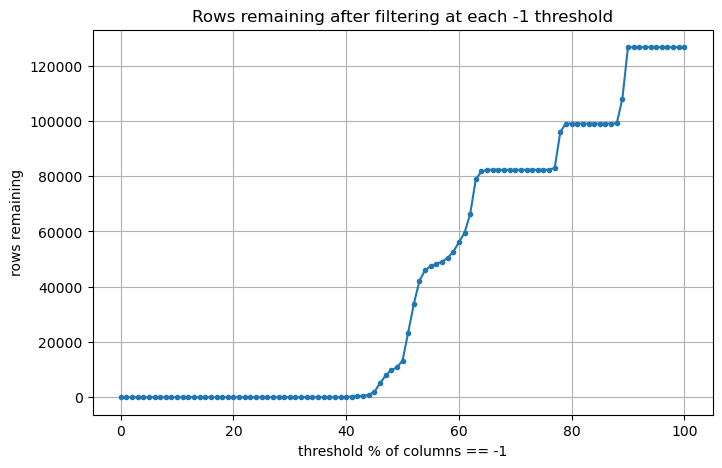

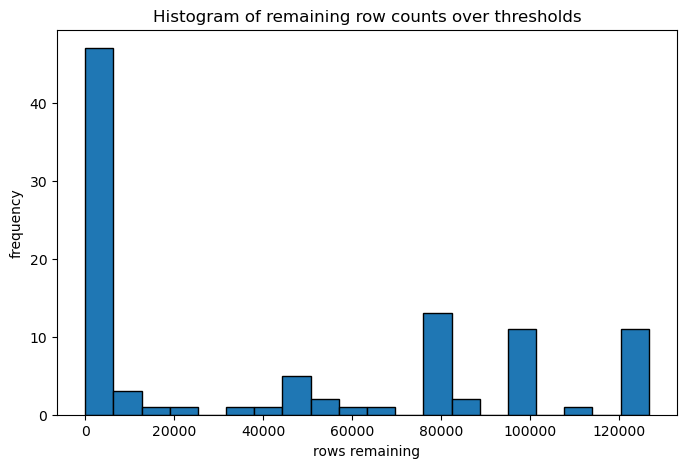

In [44]:
import numpy as np

def filter_rows_by_negative_one_pct(df, threshold=0.2, missing_value=-1, inplace=False):
    # threshold: fraction of cols with missing_value to mark row as bad
    # e.g. 0.5 means ">= 50% of columns are -1"
    bad = (df == missing_value).sum(axis=1) / df.shape[1] >= threshold
    n_bad = int(bad.sum())
    n_total = len(df)
    print(f"{n_bad} rows out of {n_total} have >= {threshold*100:.1f}% of columns == {missing_value}")
    if inplace:
        df.drop(index=df[bad].index, inplace=True)
        print(f"dropped {n_bad} rows, remaining {len(df)} rows")
        return df
    df_clean = df.loc[~bad].reset_index(drop=True)
    print(f"returning cleaned df with {len(df_clean)} rows")
    return df_clean

# example
df_clean = filter_rows_by_negative_one_pct(data)
import matplotlib.pyplot as plt

thresholds = np.linspace(0.0, 1.0, 101)
remaining_counts = []

for t in thresholds:
    df_tmp = filter_rows_by_negative_one_pct(data, threshold=t)
    remaining_counts.append(len(df_tmp))

print("data original shape:", data.shape)
print("rows remaining at thresholds (0..100%):", remaining_counts[:5], "...", remaining_counts[-5:])

plt.figure(figsize=(8, 5))
plt.plot(thresholds * 100, remaining_counts, marker="o", markersize=3)
plt.xlabel("threshold % of columns == -1")
plt.ylabel("rows remaining")
plt.title("Rows remaining after filtering at each -1 threshold")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(remaining_counts, bins=20, edgecolor="k")
plt.xlabel("rows remaining")
plt.ylabel("frequency")
plt.title("Histogram of remaining row counts over thresholds")
plt.show()